# Crosslinking and time evolution of contact maps

This notebook explores how chromatin structure evolves over time under different levels of crosslinking, using time-resolved contact probabilities and selected contact maps.

## Purpose

- Load processed observables for multiple crosslinking strengths  
- Compare contact probability curves as a function of genomic distance  
- Analyze structural preservation via mean-square displacement (RMSD proxy)  
- Visualize representative contact maps at selected time points  

## Data organization

- All datasets are stored in:  
  `../../data/processed/crosslinking_time_evolution/`

**Note:** The `.npz` datasets required for this notebook are not included in this repository and are available on Zenodo: https://doi.org/10.5281/zenodo.19682913

- Each `.npz` file contains:
  - `contact_prob_average` (contact probability vs genomic distance)  
  - `mean_square_disp` (structural evolution over time)  
  - `nsnapshots`, `iframes`, `nf`, `n_files`  

- **Contact and distance maps are included only for two representative cases:**
  - `xlbeads = 0` (no crosslinking, structural degradation)  
  - `xlbeads = 3000` (strong crosslinking, structural preservation)  

## Notes

- This notebook supports selected supplementary figures and illustrates key trends.  
- Full grids of contact and distance maps across all parameter combinations are not included to reduce dataset size.  
- Quantitative observables provided here are sufficient to reproduce the main conclusions.  

In [1]:
import hoomd, hoomd.md
import mdtraj as md
import mbuild as mb
import numpy  as np
import random
import os.path
import sys
import scipy as sp
from scipy.spatial import distance
import gsd
import gsd.fl, gsd.hoomd
import warnings
warnings.filterwarnings('ignore')

import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.sparse as sparse
from matplotlib.colors import LinearSegmentedColormap

In [ ]:
#Import data

output_dir = "../../data/processed/crosslinking_time_evolution/"
g_0000=np.load(output_dir+'xlinked_distance_contact_map_C_7_region_95.4-96.5_nkeep_4500_xlbeads_0_rc_1.5_diff_trimmed.npz', allow_pickle=True)
g_0100=np.load(output_dir+'xlinked_distance_contact_map_C_7_region_95.4-96.5_nkeep_4500_xlbeads_100_rc_1.5_diff_trimmed.npz', allow_pickle=True)
g_0500=np.load(output_dir+'xlinked_distance_contact_map_C_7_region_95.4-96.5_nkeep_4500_xlbeads_500_rc_1.5_diff_trimmed.npz', allow_pickle=True)
g_1000=np.load(output_dir+'xlinked_distance_contact_map_C_7_region_95.4-96.5_nkeep_4500_xlbeads_1000_rc_1.5_diff_trimmed.npz', allow_pickle=True)
g_3000=np.load(output_dir+'xlinked_distance_contact_map_C_7_region_95.4-96.5_nkeep_4500_xlbeads_3000_rc_1.5_diff_trimmed.npz', allow_pickle=True)
g_5000=np.load(output_dir+'xlinked_distance_contact_map_C_7_region_95.4-96.5_nkeep_4500_xlbeads_5000_rc_1.5_diff_trimmed.npz', allow_pickle=True)
g_5500=np.load(output_dir+'xlinked_distance_contact_map_C_7_region_95.4-96.5_nkeep_4500_xlbeads_5500_rc_1.5_diff_trimmed.npz', allow_pickle=True)

In [4]:
print(g_5500.files)
print(g_5000.files)
print(g_3000.files)
print(g_1000.files)
print(g_0500.files)
print(g_0100.files)
print(g_0000.files)

['iframes', 'nsnapshots', 'distance_map_average', 'contact_map_average', 'contact_prob_average', 'nf', 'n_files', 'mean_square_disp']
['iframes', 'nsnapshots', 'distance_map_average', 'contact_map_average', 'contact_prob_average', 'nf', 'n_files', 'mean_square_disp']
['iframes', 'nsnapshots', 'distance_map_average', 'contact_map_average', 'contact_prob_average', 'nf', 'n_files', 'mean_square_disp']
['iframes', 'nsnapshots', 'distance_map_average', 'contact_map_average', 'contact_prob_average', 'nf', 'n_files', 'mean_square_disp']
['iframes', 'nsnapshots', 'distance_map_average', 'contact_map_average', 'contact_prob_average', 'nf', 'n_files', 'mean_square_disp']
['iframes', 'nsnapshots', 'distance_map_average', 'contact_map_average', 'contact_prob_average', 'nf', 'n_files', 'mean_square_disp']
['iframes', 'nsnapshots', 'distance_map_average', 'contact_map_average', 'contact_prob_average', 'nf', 'n_files', 'mean_square_disp']


In [ ]:
nsnap_5500 = g_5500['nsnapshots']
iframes_5500 = g_5500['iframes']
cont_prob_5500 = g_5500['contact_prob_average']
nf_5500 = g_5500['nf']
n_files_5500 = g_5500['n_files']
msd_5500 = g_5500['mean_square_disp']

nsnap_5000 = g_5000['nsnapshots']
iframes_5000 = g_5000['iframes']
cont_prob_5000 = g_5000['contact_prob_average']
nf_5000 = g_5000['nf']
n_files_5000 = g_5000['n_files']
msd_5000 = g_5000['mean_square_disp']

nsnap_3000 = g_3000['nsnapshots']
iframes_3000 = g_3000['iframes']
dist_map_3000 = g_3000['distance_map_average']
cont_map_3000 = g_3000['contact_map_average']
cont_prob_3000 = g_3000['contact_prob_average']
nf_3000 = g_3000['nf']
n_files_3000 = g_3000['n_files']
msd_3000 = g_3000['mean_square_disp']

nsnap_1000 = g_1000['nsnapshots']
iframes_1000 = g_1000['iframes']
cont_prob_1000 = g_1000['contact_prob_average']
nf_1000 = g_1000['nf']
n_files_1000 = g_1000['n_files']
msd_1000 = g_1000['mean_square_disp']

nsnap_0500 = g_0500['nsnapshots']
iframes_0500 = g_0500['iframes']
cont_prob_0500 = g_0500['contact_prob_average']
nf_0500 = g_0500['nf']
n_files_0500 = g_0500['n_files']
msd_0500 = g_0500['mean_square_disp']

nsnap_0100 = g_0100['nsnapshots']
iframes_0100 = g_0100['iframes']
cont_prob_0100 = g_0100['contact_prob_average']
nf_0100 = g_0100['nf']
n_files_0100 = g_0100['n_files']
msd_0100 = g_0100['mean_square_disp']

nsnap_0000 = g_0000['nsnapshots']
iframes_0000 = g_0000['iframes']
dist_map_0000 = g_0000['distance_map_average']
cont_map_0000 = g_0000['contact_map_average']
cont_prob_0000 = g_0000['contact_prob_average']
nf_0000 = g_0000['nf']
n_files_0000 = g_0000['n_files']
msd_0000 = g_0000['mean_square_disp']

In [ ]:
#dist_map_5500 = g_5500['distance_map_average']
#cont_map_5500 = g_5500['contact_map_average']
#cont_prob_5500 = g_5500['contact_prob_average']
#nf_5500 = g_5500['nf']

nsnap_5000 = g_5000['nsnapshots']
iframes_5000 = g_5000['iframes']
cont_prob_5000 = g_5000['contact_prob_average']
nf_5000 = g_5000['nf']
n_files_5000 = g_5000['n_files']
msd_5000 = g_5000['mean_square_disp']

nsnap_3000 = g_3000['nsnapshots']
iframes_3000 = g_3000['iframes']
dist_map_3000 = g_3000['distance_map_average']
cont_map_3000 = g_3000['contact_map_average']
cont_prob_3000 = g_3000['contact_prob_average']
nf_3000 = g_3000['nf']
n_files_3000 = g_3000['n_files']
msd_3000 = g_3000['mean_square_disp']

nsnap_1500 = g_1500['nsnapshots']
iframes_1500 = g_1500['iframes']
cont_prob_1500 = g_1500['contact_prob_average']
nf_1500 = g_1500['nf']
n_files_1500 = g_1500['n_files']
msd_1500 = g_1500['mean_square_disp']

nsnap_1000 = g_1000['nsnapshots']
iframes_1000 = g_1000['iframes']
cont_prob_1000 = g_1000['contact_prob_average']
nf_1000 = g_1000['nf']
n_files_1000 = g_1000['n_files']
msd_1000 = g_1000['mean_square_disp']

nsnap_0500 = g_0500['nsnapshots']
iframes_0500 = g_0500['iframes']
cont_prob_0500 = g_0500['contact_prob_average']
nf_0500 = g_0500['nf']
n_files_0500 = g_0500['n_files']
msd_0500 = g_0500['mean_square_disp']

nsnap_0100 = g_0100['nsnapshots']
iframes_0100 = g_0100['iframes']
cont_prob_0100 = g_0100['contact_prob_average']
nf_0100 = g_0100['nf']
n_files_0100 = g_0100['n_files']
msd_0100 = g_0100['mean_square_disp']

#dist_map_0000 = g_0000['distance_map_average']
#cont_map_0000 = g_0000['contact_map_average']
#cont_prob_0000 = g_0000['contact_prob_average']
#nf_0000 = g_0000['nf']

In [10]:
print(nf_0000, nf_0100, nf_0500, nf_1000, nf_3000, nf_5000, nf_5500)
print(n_files_0000, n_files_0100, n_files_0500, n_files_1000, n_files_3000, n_files_5000, n_files_5500)

5097 5082 5074 5075 5053 5012 5000
[5000. 5000. 5000. 5000. 5000. 5000. 5000. 5000. 5000.] [5000. 5000. 5000. 5000. 5000. 5000. 5000. 5000. 5000.] [5000. 5000. 5000. 5000. 5000. 5000. 5000. 5000. 5000.] [5000. 5000. 5000. 5000. 5000. 5000. 5000. 5000. 5000.] [5000. 5000. 5000. 5000. 5000. 5000. 5000. 5000. 5000.] [5000. 5000. 5000. 5000. 5000. 5000. 5000. 5000. 5000.] [5000. 5000. 5000. 5000. 5000. 5000. 5000. 5000. 5000.]


In [12]:
iframes_0500

array([   0,   99,  249,  499,  749,  999, 1249, 2499, 4999])

In [126]:
degrade_legend = ['t = '+str(0)+r'$\tau$','t = '+str(100)+r'$\tau$','t = '+str(250)+r'$\tau$','t = '+str(500)+r'$\tau$','t = '+str(750)+r'$\tau$','t = '+str(1000)+r'$\tau$','t = '+str(1250)+r'$\tau$','t = '+str(2500)+r'$\tau$','t = '+str(5000)+r'$\tau$']

In [16]:
degrade_legend = ['t = '+str(0)+r'$\tau$','t = '+str(100)+r'$\tau$','t = '+str(250)+r'$\tau$','t = '+str(500)+r'$\tau$','t = '+str(750)+r'$\tau$','t = '+str(1000)+r'$\tau$','t = '+str(1250)+r'$\tau$','t = '+str(2500)+r'$\tau$','t = '+str(5000)+r'$\tau$']

In [ ]:
#Non-equilibirum effects of diffusion on contact probability at different time slices.
#Larger crosslinking efficiencies help preserve structural information about chromosome conformations.

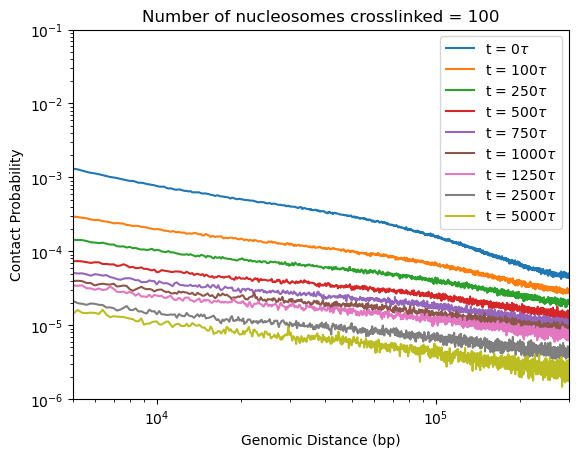

In [127]:
xticks = np.linspace(1, 5500, 5499)
scale_factor = 200
scaled_xticks = scale_factor*xticks

for i in range(nsnap_0100):
    plt.plot(scaled_xticks, cont_prob_0100[i])


plt.legend(degrade_legend, loc='upper right')
plt.xlim([0,5500])
plt.ylabel('Contact Probability')
plt.yscale("log")
plt.xscale("log")
plt.title("Number of nucleosomes crosslinked = 100")
plt.xlim([1,5500])
plt.ylim([1e-8,1e1])

plt.xlim([scale_factor*1,scale_factor*5500])

plt.ylim([1e-6,1e-1])
plt.xlim(5000, 300000)
plt.xlabel('Genomic Distance (bp)')

plt.show()

#Notice that the curve for p=1 has a very large number of ligations happening at a genomic distance of 1, meaning most of the ligations take place
#immediately, without the system having any chance to move. This explains why the p=1 curve seems to break the ordered pattern that the rest of the
#probability rates follow

In [151]:
scaled_xticks[49]

10001.7824663514

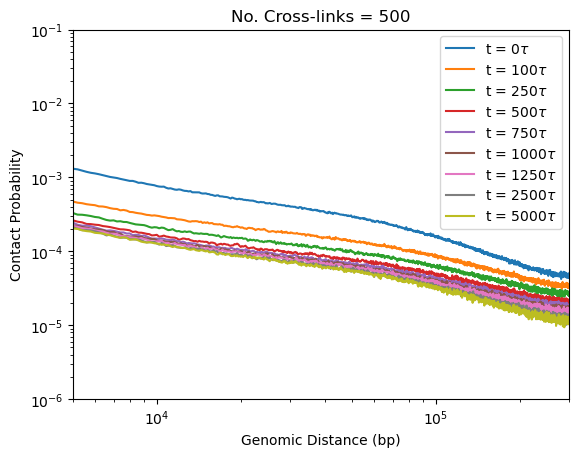

In [21]:

xticks = np.linspace(1, 5500, 5499)

scale_factor = 200
scaled_xticks = scale_factor*xticks

for i in range(nsnap_0500):
    plt.plot(scaled_xticks, cont_prob_0500[i])


plt.legend(degrade_legend, loc='upper right')
plt.xlim([0,5500])
plt.ylabel('Contact Probability')
plt.yscale("log")
plt.xscale("log")
plt.title("No. Cross-links = 500")
plt.xlim([1,5500])
plt.ylim([1e-8,1e1])


plt.xlim([scale_factor*1,scale_factor*5500])

plt.ylim([1e-6,1e-1])
plt.xlim(5000, 300000)
plt.xlabel('Genomic Distance (bp)')

plt.show()

#Notice that the curve for p=1 has a very large number of ligations happening at a genomic distance of 1, meaning most of the ligations take place
#immediately, without the system having any chance to move. This explains why the p=1 curve seems to break the ordered pattern that the rest of the
#probability rates follow

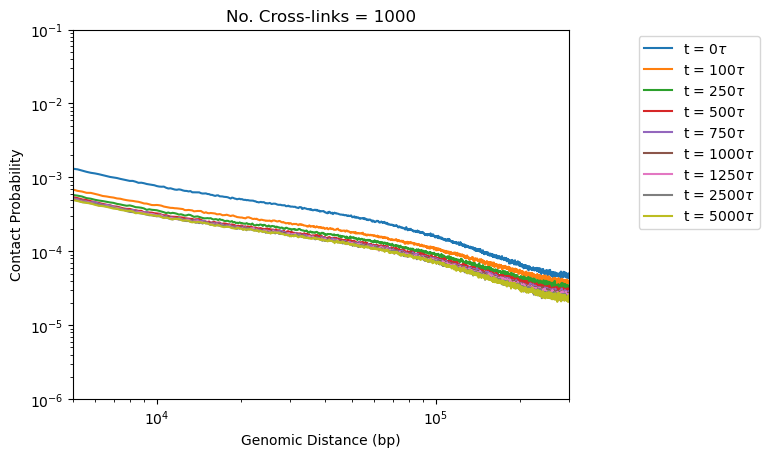

In [22]:

xticks = np.linspace(1, 5500, 5499)

scale_factor = 200
scaled_xticks = scale_factor*xticks

for i in range(nsnap_1000):
    plt.plot(scaled_xticks, cont_prob_1000[i])


plt.legend(degrade_legend, loc='upper right', bbox_to_anchor=(1.4, 1.0))
plt.xlim([0,5500])
plt.ylabel('Contact Probability')
plt.yscale("log")
plt.xscale("log")
plt.title("No. Cross-links = 1000")
plt.xlim([1,5500])
plt.ylim([1e-8,1e1])


plt.xlim([scale_factor*1,scale_factor*5500])


plt.ylim([1e-6,1e-1])
plt.xlim(5000, 300000)
plt.xlabel('Genomic Distance (bp)')

plt.show()

#Notice that the curve for p=1 has a very large number of ligations happening at a genomic distance of 1, meaning most of the ligations take place
#immediately, without the system having any chance to move. This explains why the p=1 curve seems to break the ordered pattern that the rest of the
#probability rates follow

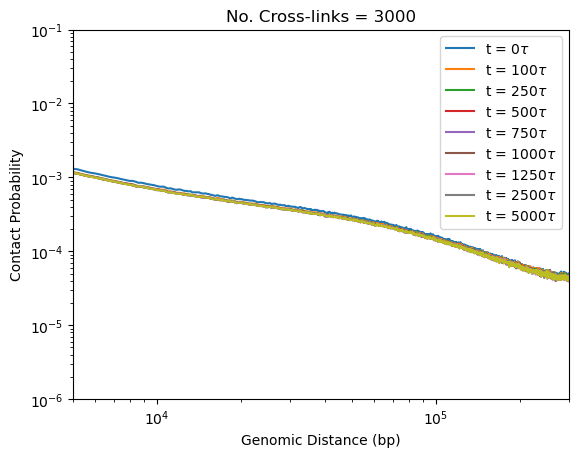

In [25]:

xticks = np.linspace(1, 5500, 5499)

scale_factor = 200
scaled_xticks = scale_factor*xticks

for i in range(nsnap_3000):
    plt.plot(scaled_xticks, cont_prob_3000[i])


plt.legend(degrade_legend, loc='upper right')
plt.xlim([0,5500])
plt.ylabel('Contact Probability')
plt.yscale("log")
plt.xscale("log")
plt.title("No. Cross-links = 3000")
plt.xlim([1,5500])
plt.ylim([1e-8,1e1])


plt.xlim([scale_factor*1,scale_factor*5500])

plt.ylim([1e-6,1e-1])
plt.xlim(5000, 300000)
plt.xlabel('Genomic Distance (bp)')

plt.show()

#Notice that the curve for p=1 has a very large number of ligations happening at a genomic distance of 1, meaning most of the ligations take place
#immediately, without the system having any chance to move. This explains why the p=1 curve seems to break the ordered pattern that the rest of the
#probability rates follow

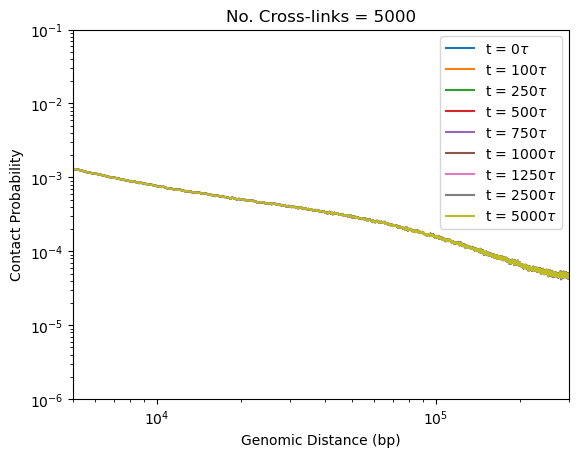

In [26]:

xticks = np.linspace(1, 5500, 5499)

scale_factor = 200
scaled_xticks = scale_factor*xticks

for i in range(nsnap_5000):
    plt.plot(scaled_xticks, cont_prob_5000[i])


plt.legend(degrade_legend, loc='upper right')
plt.xlim([0,5500])
plt.ylabel('Contact Probability')
plt.yscale("log")
plt.xscale("log")
plt.title("No. Cross-links = 5000")
plt.xlim([1,5500])
plt.ylim([1e-8,1e1])


plt.xlim([scale_factor*1,scale_factor*5500])

plt.ylim([1e-6,1e-1])
plt.xlim(5000, 300000)
plt.xlabel('Genomic Distance (bp)')

plt.show()

#Notice that the curve for p=1 has a very large number of ligations happening at a genomic distance of 1, meaning most of the ligations take place
#immediately, without the system having any chance to move. This explains why the p=1 curve seems to break the ordered pattern that the rest of the
#probability rates follow

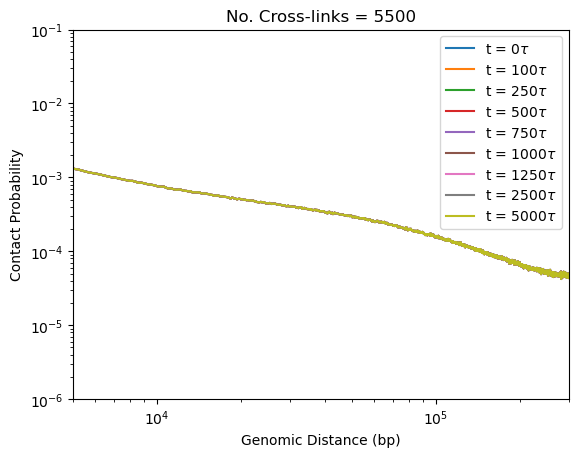

In [27]:

xticks = np.linspace(1, 5500, 5499)

scale_factor = 200
scaled_xticks = scale_factor*xticks

for i in range(nsnap_5500):
    plt.plot(scaled_xticks, cont_prob_5500[i])


plt.legend(degrade_legend, loc='upper right')
plt.xlim([0,5500])
plt.ylabel('Contact Probability')
plt.yscale("log")
plt.xscale("log")
plt.title("No. Cross-links = 5500")
plt.xlim([1,5500])
plt.ylim([1e-8,1e1])


plt.xlim([scale_factor*1,scale_factor*5500])

plt.ylim([1e-6,1e-1])
plt.xlim(5000, 300000)
plt.xlabel('Genomic Distance (bp)')

plt.show()

#Notice that the curve for p=1 has a very large number of ligations happening at a genomic distance of 1, meaning most of the ligations take place
#immediately, without the system having any chance to move. This explains why the p=1 curve seems to break the ordered pattern that the rest of the
#probability rates follow

In [ ]:
#Non-equilibirum effects of diffusion on contact probability at crosslinking efficiencies.
#With increasing diffusion time, the least crosslinked structures exhibit a flattening of their power-law scalings due to structural loss of the map.
#Highly crosslinked structures, however, retain the informational contents of the conformations.

In [31]:
degrade_legend = ['No. Cross-links = '+str(0), 'No. Cross-links = '+str(100), 'No. Cross-links = '+str(500),'No. Cross-links = '+str(1000),'No. Cross-links = '+str(3000),'No. Cross-links = '+str(5000),'No. Cross-links = '+str(5500)]


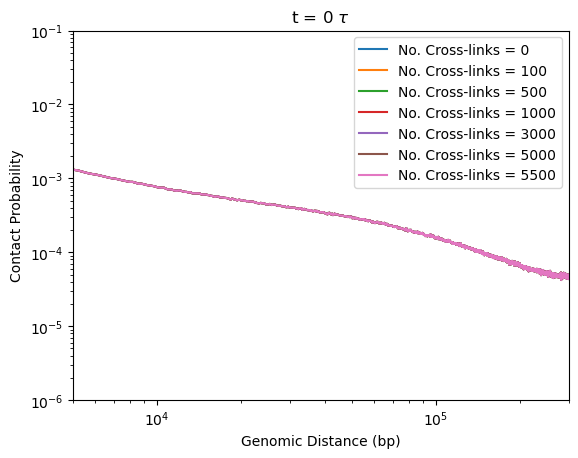

In [32]:

xticks = np.linspace(1, 5500, 5499)

scale_factor = 200
scaled_xticks = scale_factor*xticks

plt.plot(scaled_xticks, cont_prob_0000[0])
plt.plot(scaled_xticks, cont_prob_0100[0])
plt.plot(scaled_xticks, cont_prob_0500[0])
plt.plot(scaled_xticks, cont_prob_1000[0])
plt.plot(scaled_xticks, cont_prob_3000[0])
plt.plot(scaled_xticks, cont_prob_5000[0])
plt.plot(scaled_xticks, cont_prob_5500[0])


plt.legend(degrade_legend, loc='upper right')
plt.xlim([0,5500])
plt.ylabel('Contact Probability')
plt.yscale("log")
plt.xscale("log")
plt.title("t = 0" + r' $\tau$')
plt.xlim([1,5500])
plt.ylim([1e-8,1e1])


plt.xlim([scale_factor*1,scale_factor*5500])

plt.ylim([1e-6,1e-1])
plt.xlim(5000, 300000)
plt.xlabel('Genomic Distance (bp)')

plt.show()

#Notice that the curve for p=1 has a very large number of ligations happening at a genomic distance of 1, meaning most of the ligations take place
#immediately, without the system having any chance to move. This explains why the p=1 curve seems to break the ordered pattern that the rest of the
#probability rates follow

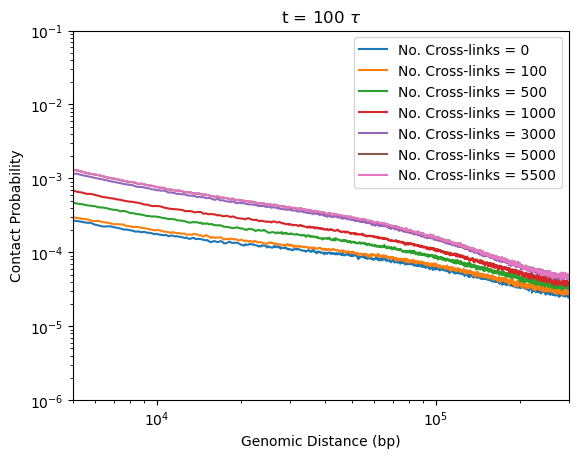

In [33]:

xticks = np.linspace(1, 5500, 5499)

scale_factor = 200
scaled_xticks = scale_factor*xticks


plt.plot(scaled_xticks, cont_prob_0000[1])
plt.plot(scaled_xticks, cont_prob_0100[1])
plt.plot(scaled_xticks, cont_prob_0500[1])
plt.plot(scaled_xticks, cont_prob_1000[1])
plt.plot(scaled_xticks, cont_prob_3000[1])
plt.plot(scaled_xticks, cont_prob_5000[1])
plt.plot(scaled_xticks, cont_prob_5500[1])


plt.legend(degrade_legend, loc='upper right')
plt.xlim([0,5500])
plt.ylabel('Contact Probability')
plt.yscale("log")
plt.xscale("log")
plt.title("t = 100" + r' $\tau$')
plt.xlim([1,5500])
plt.ylim([1e-8,1e1])


plt.xlim([scale_factor*1,scale_factor*5500])

plt.ylim([1e-6,1e-1])
plt.xlim(5000, 300000)
plt.xlabel('Genomic Distance (bp)')

plt.show()

#Notice that the curve for p=1 has a very large number of ligations happening at a genomic distance of 1, meaning most of the ligations take place
#immediately, without the system having any chance to move. This explains why the p=1 curve seems to break the ordered pattern that the rest of the
#probability rates follow

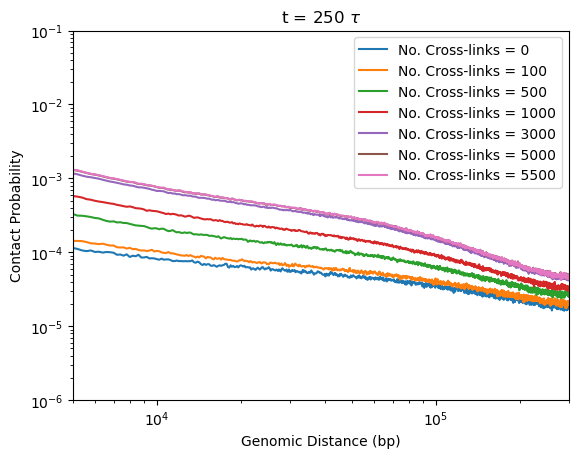

In [34]:

xticks = np.linspace(1, 5500, 5499)

scale_factor = 200
scaled_xticks = scale_factor*xticks


plt.plot(scaled_xticks, cont_prob_0000[2])
plt.plot(scaled_xticks, cont_prob_0100[2])
plt.plot(scaled_xticks, cont_prob_0500[2])
plt.plot(scaled_xticks, cont_prob_1000[2])
plt.plot(scaled_xticks, cont_prob_3000[2])
plt.plot(scaled_xticks, cont_prob_5000[2])
plt.plot(scaled_xticks, cont_prob_5500[2])


plt.legend(degrade_legend, loc='upper right')
plt.xlim([0,5500])
plt.ylabel('Contact Probability')
plt.yscale("log")
plt.xscale("log")
plt.title("t = 250" + r' $\tau$')
plt.xlim([1,5500])
plt.ylim([1e-8,1e1])


plt.xlim([scale_factor*1,scale_factor*5500])

plt.ylim([1e-6,1e-1])
plt.xlim(5000, 300000)
plt.xlabel('Genomic Distance (bp)')

plt.show()

#Notice that the curve for p=1 has a very large number of ligations happening at a genomic distance of 1, meaning most of the ligations take place
#immediately, without the system having any chance to move. This explains why the p=1 curve seems to break the ordered pattern that the rest of the
#probability rates follow

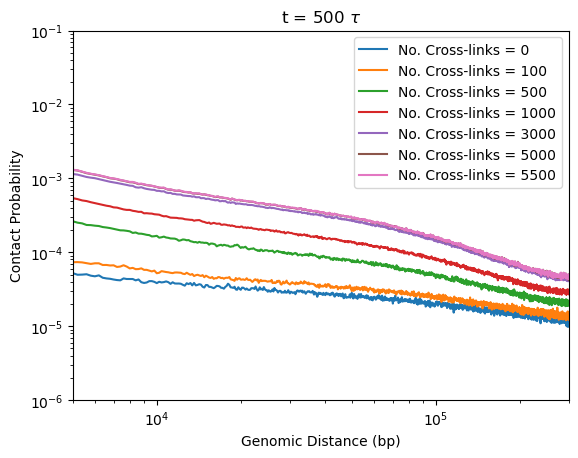

In [37]:


xticks = np.linspace(1, 5500, 5499)

scale_factor = 200
scaled_xticks = scale_factor*xticks

plt.plot(scaled_xticks, cont_prob_0000[3])
plt.plot(scaled_xticks, cont_prob_0100[3])
plt.plot(scaled_xticks, cont_prob_0500[3])
plt.plot(scaled_xticks, cont_prob_1000[3])
plt.plot(scaled_xticks, cont_prob_3000[3])
plt.plot(scaled_xticks, cont_prob_5000[3])
plt.plot(scaled_xticks, cont_prob_5500[3])


plt.legend(degrade_legend, loc='upper right')
plt.xlim([0,5500])
plt.ylabel('Contact Probability')
plt.yscale("log")
plt.xscale("log")
plt.title("t = 500" + r' $\tau$')
plt.xlim([1,5500])
plt.ylim([1e-8,1e1])


plt.xlim([scale_factor*1,scale_factor*5500])

plt.ylim([1e-6,1e-1])
plt.xlim(5000, 300000)
plt.xlabel('Genomic Distance (bp)')

plt.show()

#Notice that the curve for p=1 has a very large number of ligations happening at a genomic distance of 1, meaning most of the ligations take place
#immediately, without the system having any chance to move. This explains why the p=1 curve seems to break the ordered pattern that the rest of the
#probability rates follow

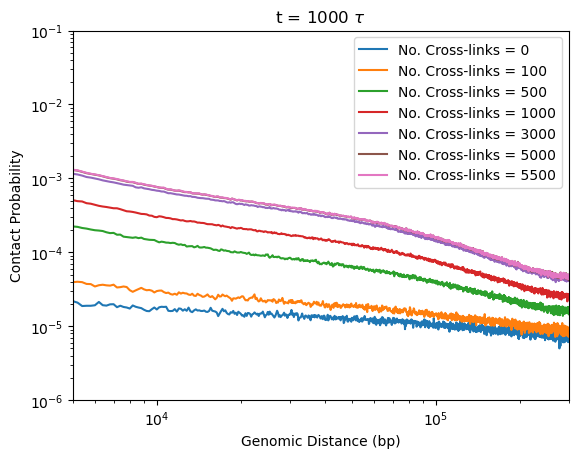

In [39]:


xticks = np.linspace(1, 5500, 5499)

scale_factor = 200
scaled_xticks = scale_factor*xticks


plt.plot(scaled_xticks, cont_prob_0000[5])
plt.plot(scaled_xticks, cont_prob_0100[5])
plt.plot(scaled_xticks, cont_prob_0500[5])
plt.plot(scaled_xticks, cont_prob_1000[5])
plt.plot(scaled_xticks, cont_prob_3000[5])
plt.plot(scaled_xticks, cont_prob_5000[5])
plt.plot(scaled_xticks, cont_prob_5500[5])


plt.legend(degrade_legend, loc='upper right') # bbox_to_anchor=(1.4, 1.0))
plt.xlim([0,5500])
plt.ylabel('Contact Probability')
plt.yscale("log")
plt.xscale("log")
plt.title("t = 1000" + r' $\tau$')
plt.xlim([1,5500])
plt.ylim([1e-8,1e1])


plt.xlim([scale_factor*1,scale_factor*5500])

plt.ylim([1e-6,1e-1])
plt.xlim(5000, 300000)
plt.xlabel('Genomic Distance (bp)')

plt.show()

#Notice that the curve for p=1 has a very large number of ligations happening at a genomic distance of 1, meaning most of the ligations take place
#immediately, without the system having any chance to move. This explains why the p=1 curve seems to break the ordered pattern that the rest of the
#probability rates follow

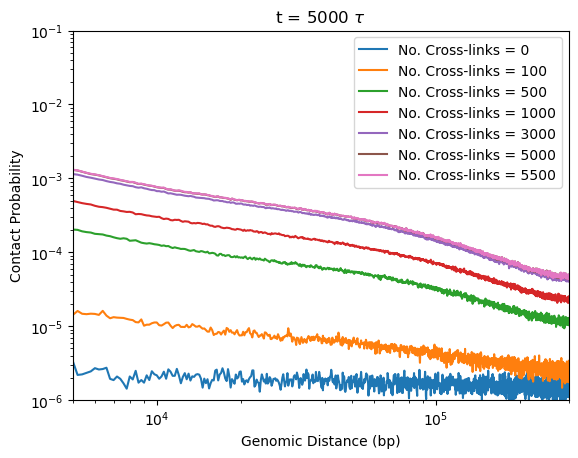

In [41]:


xticks = np.linspace(1, 5500, 5499)

scale_factor = 200
scaled_xticks = scale_factor*xticks


plt.plot(scaled_xticks, cont_prob_0000[8])
plt.plot(scaled_xticks, cont_prob_0100[8])
plt.plot(scaled_xticks, cont_prob_0500[8])
plt.plot(scaled_xticks, cont_prob_1000[8])
plt.plot(scaled_xticks, cont_prob_3000[8])
plt.plot(scaled_xticks, cont_prob_5000[8])
plt.plot(scaled_xticks, cont_prob_5500[8])


plt.legend(degrade_legend, loc='upper right')
plt.xlim([0,5500])
plt.ylabel('Contact Probability')
plt.yscale("log")
plt.xscale("log")
plt.title("t = 5000" + r' $\tau$')
plt.xlim([1,5500])
plt.ylim([1e-8,1e1])


plt.xlim([scale_factor*1,scale_factor*5500])

plt.ylim([1e-6,1e-1])
plt.xlim(5000, 300000)
plt.xlabel('Genomic Distance (bp)')

plt.show()



In [ ]:
#Mean squared displacement of nucleosomes as a function of time for different crosslinking efficiencies

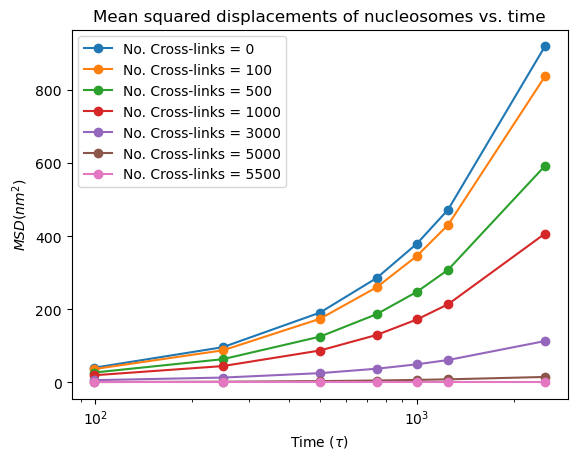

In [43]:
plt.plot(iframes_0000[1:-1], msd_0000[1:-1], marker = 'o')
plt.plot(iframes_0100[1:-1], msd_0100[1:-1], marker = 'o')
plt.plot(iframes_0500[1:-1], msd_0500[1:-1], marker = 'o')
plt.plot(iframes_1000[1:-1], msd_1000[1:-1], marker = 'o')
plt.plot(iframes_3000[1:-1], msd_3000[1:-1], marker = 'o')
plt.plot(iframes_5000[1:-1], msd_5000[1:-1], marker = 'o')
plt.plot(iframes_5500[1:-1], msd_5500[1:-1], marker = 'o')


plt.legend(degrade_legend, loc='upper left')
#plt.xlim([0,5500])
plt.ylabel(r'$MSD (nm^2)$')
#plt.yscale("log")
plt.xscale("log")
plt.title("Mean squared displacements of nucleosomes vs. time")
#plt.xlim([1,5500])
#plt.ylim([1e1,1e1])


#plt.xlim([scale_factor*1,scale_factor*5500])
plt.xlabel('Time ('+r'$\tau$)')

plt.show()



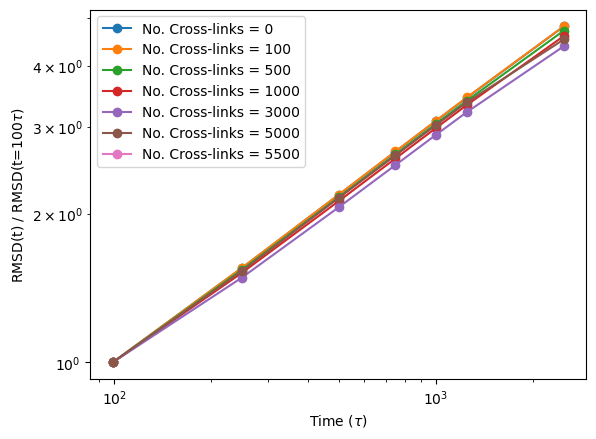

In [52]:
plt.plot(iframes_0000[1:-1], np.sqrt(msd_0000[1:-1]/msd_0000[1]), marker = 'o')
plt.plot(iframes_0100[1:-1], np.sqrt(msd_0100[1:-1]/msd_0100[1]), marker = 'o')
plt.plot(iframes_0500[1:-1], np.sqrt(msd_0500[1:-1]/msd_0500[1]), marker = 'o')
plt.plot(iframes_1000[1:-1], np.sqrt(msd_1000[1:-1]/msd_1000[1]), marker = 'o')
plt.plot(iframes_3000[1:-1], np.sqrt(msd_3000[1:-1]/msd_3000[1]), marker = 'o')
plt.plot(iframes_5000[1:-1], np.sqrt(msd_5000[1:-1]/msd_5000[1]), marker = 'o')
plt.plot(iframes_5500[1:-1], np.sqrt(msd_5500[1:-1]/msd_5500[1]), marker = 'o')


plt.legend(degrade_legend, loc='upper left')
#plt.xlim([0,5500])
plt.ylabel('RMSD(t) / RMSD(t=100'+r'$\tau$)')
plt.yscale("log")
plt.xscale("log")
#plt.title("Mean squared displacements of nucleosomes vs. time")
#plt.xlim([1,5500])
#plt.ylim([1e1,1e1])


#plt.xlim([scale_factor*1,scale_factor*5500])
plt.xlabel('Time ('+r'$\tau$)')

plt.show()


In [ ]:
#Grid of average distance maps as a function of time and crosslinking efficiency.
#The non-equilibirum informational degradation in the absence of crosslinking manifests as a loss of evidence for domains, compartments, etc.

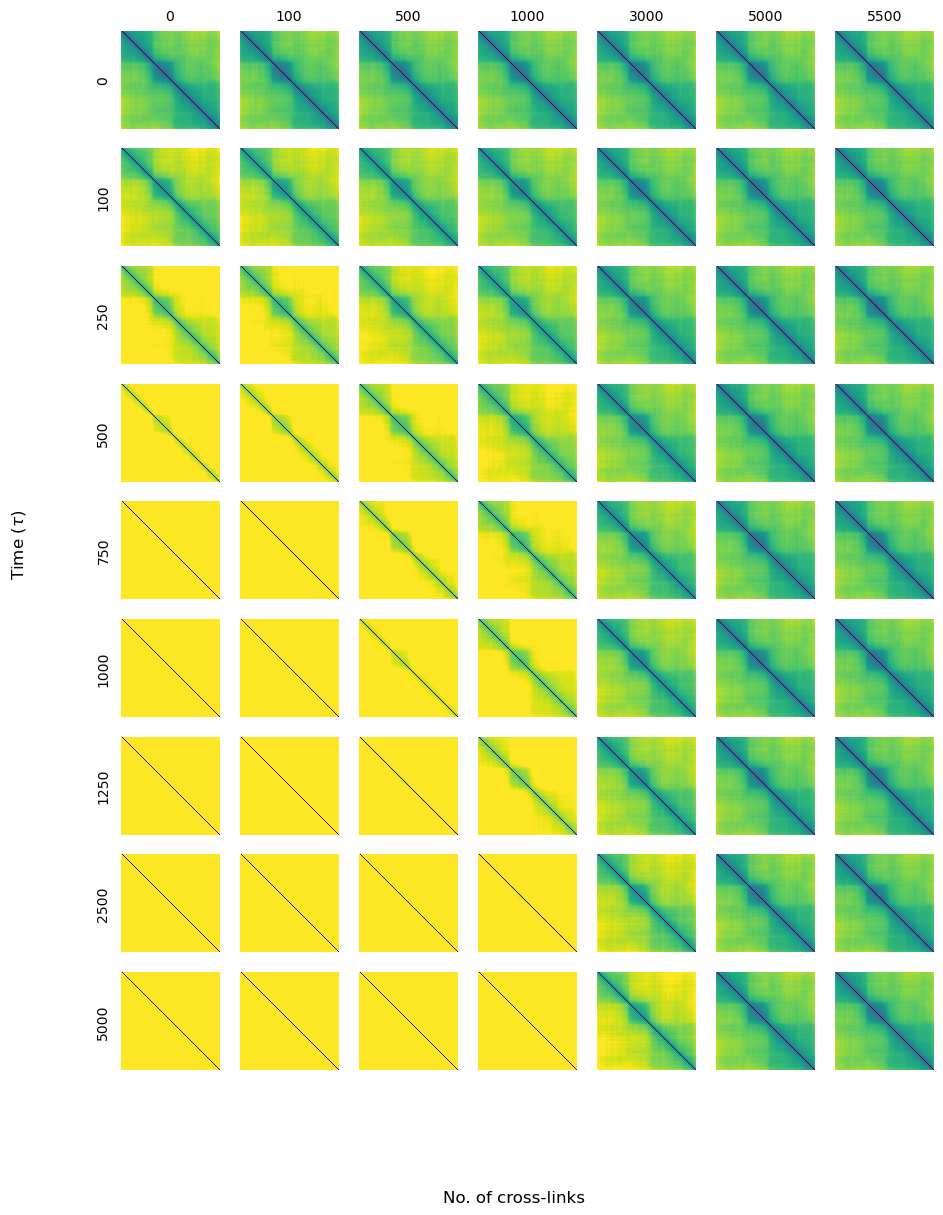

In [ ]:
No_xlbeads = [0, 100, 500, 1000, 3000, 5000, 5500]
times = [0,100,250,500,750,1000,1250,2500,5000]

scalef = 1.5

fig, ax = plt.subplots(9, 7, figsize=(7*scalef,9*scalef))

v_min=0
v_max=40

#ax[0, 0].matshow(dist_map_0000,  cmap='viridis' )
#ax[0, 0].axis('off')
#ax[0, 0].set_title("No. deg. cuts = 0")

ax[0, 0].matshow(dist_map_0000[0],  cmap='viridis', vmin=v_min, vmax=v_max)
ax[0, 0].xaxis.set_tick_params(labelbottom=False, labeltop=False)
ax[0, 0].yaxis.set_tick_params(labelleft=False, labelright=False)
ax[0, 0].set_xticks([])
ax[0, 0].set_yticks([])
ax[0, 0].spines['top'].set_visible(False)
ax[0, 0].spines['bottom'].set_visible(False)
ax[0, 0].spines['left'].set_visible(False)
ax[0, 0].spines['right'].set_visible(False)
ax[0, 0].xaxis.set_label_position('top')
ax[0, 0].set_xlabel(No_xlbeads[0])
ax[0, 0].yaxis.set_label_position('left')
ax[0, 0].set_ylabel(times[0])


ax[0, 1].matshow(dist_map_0100[0],  cmap='viridis' , vmin=v_min, vmax=v_max)
ax[0, 2].matshow(dist_map_0500[0],  cmap='viridis' , vmin=v_min, vmax=v_max)
ax[0, 3].matshow(dist_map_1000[0],  cmap='viridis' , vmin=v_min, vmax=v_max)
ax[0, 4].matshow(dist_map_3000[0],  cmap='viridis' , vmin=v_min, vmax=v_max)
ax[0, 5].matshow(dist_map_5000[0],  cmap='viridis' , vmin=v_min, vmax=v_max)
ax[0, 6].matshow(dist_map_5500[0],  cmap='viridis' , vmin=v_min, vmax=v_max)

for i in range(1, 7):
    ax[0, i].xaxis.set_tick_params(labelbottom=False, labeltop=False)
    ax[0, i].yaxis.set_tick_params(labelleft=False, labelright=False)
    ax[0, i].set_xticks([])
    ax[0, i].set_yticks([])
    ax[0, i].spines['top'].set_visible(False)
    ax[0, i].spines['bottom'].set_visible(False)
    ax[0, i].spines['left'].set_visible(False)
    ax[0, i].spines['right'].set_visible(False)
    ax[0, i].xaxis.set_label_position('top')
    ax[0, i].set_xlabel(No_xlbeads[i])
    
for i in range(1, 9):
    ax[i, 0].matshow(dist_map_0000[i],  cmap='viridis' , vmin=v_min, vmax=v_max)
    ax[i, 0].xaxis.set_tick_params(labelbottom=False, labeltop=False)
    ax[i, 0].yaxis.set_tick_params(labelleft=False, labelright=False)
    ax[i, 0].set_xticks([])
    ax[i, 0].set_yticks([])
    ax[i, 0].spines['top'].set_visible(False)
    ax[i, 0].spines['bottom'].set_visible(False)
    ax[i, 0].spines['left'].set_visible(False)
    ax[i, 0].spines['right'].set_visible(False)
    ax[i, 0].set_ylabel(times[i])

    #ax[i, 1].matshow(dist_map_0100[i],  cmap='viridis' , vmin=v_min, vmax=v_max)
    ax[i, 1].axis('off')
    
    #ax[i, 2].matshow(dist_map_0500[i],  cmap='viridis' , vmin=v_min, vmax=v_max)
    ax[i, 2].axis('off')

    #ax[i, 3].matshow(dist_map_1000[i],  cmap='viridis' , vmin=v_min, vmax=v_max)
    ax[i, 3].axis('off')
    
    ax[i, 4].matshow(dist_map_3000[i],  cmap='viridis' , vmin=v_min, vmax=v_max)
    ax[i, 4].axis('off')

    #ax[i, 5].matshow(dist_map_5000[i],  cmap='viridis' , vmin=v_min, vmax=v_max)
    ax[i, 5].axis('off') 
    
    #ax[i, 6].matshow(dist_map_5500[i],  cmap='viridis' , vmin=v_min, vmax=v_max)
    ax[i, 6].axis('off') 

#plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
fig.supxlabel('No. of cross-links')
fig.supylabel('Time ('+r'$\tau$)')
#fig.suptitle("Time evolution of distance maps for different numbers of crosslinks")
#fig.subplots_adjust(hspace = 0)

plt.show()

In [ ]:
#Coarse-graining function for resolution transformation in maps.

In [78]:
def coarse(native_matrix, native_L, coarse_L):
    
    cell_length   = int(native_L/coarse_L)
    
    if (native_L%coarse_L!=0):
        print('Length of side of the native matrix is not a multiple of length of size of target coarse matrix')
    else:
        
        coarse_matrix = np.zeros((coarse_L,coarse_L))

        for i in range(0,coarse_L):
            for j in range(0,coarse_L):
                coarse_matrix[i][j] = np.sum(native_matrix[i*cell_length:(i+1)*cell_length, j*cell_length:(j+1)*cell_length])
    
    return coarse_matrix

In [ ]:
#Grid of average contact maps as a function of time and crosslinking efficiency.
#The non-equilibirum informational degradation in the absence of crosslinking manifests as a loss of evidence for domains, compartments, etc.

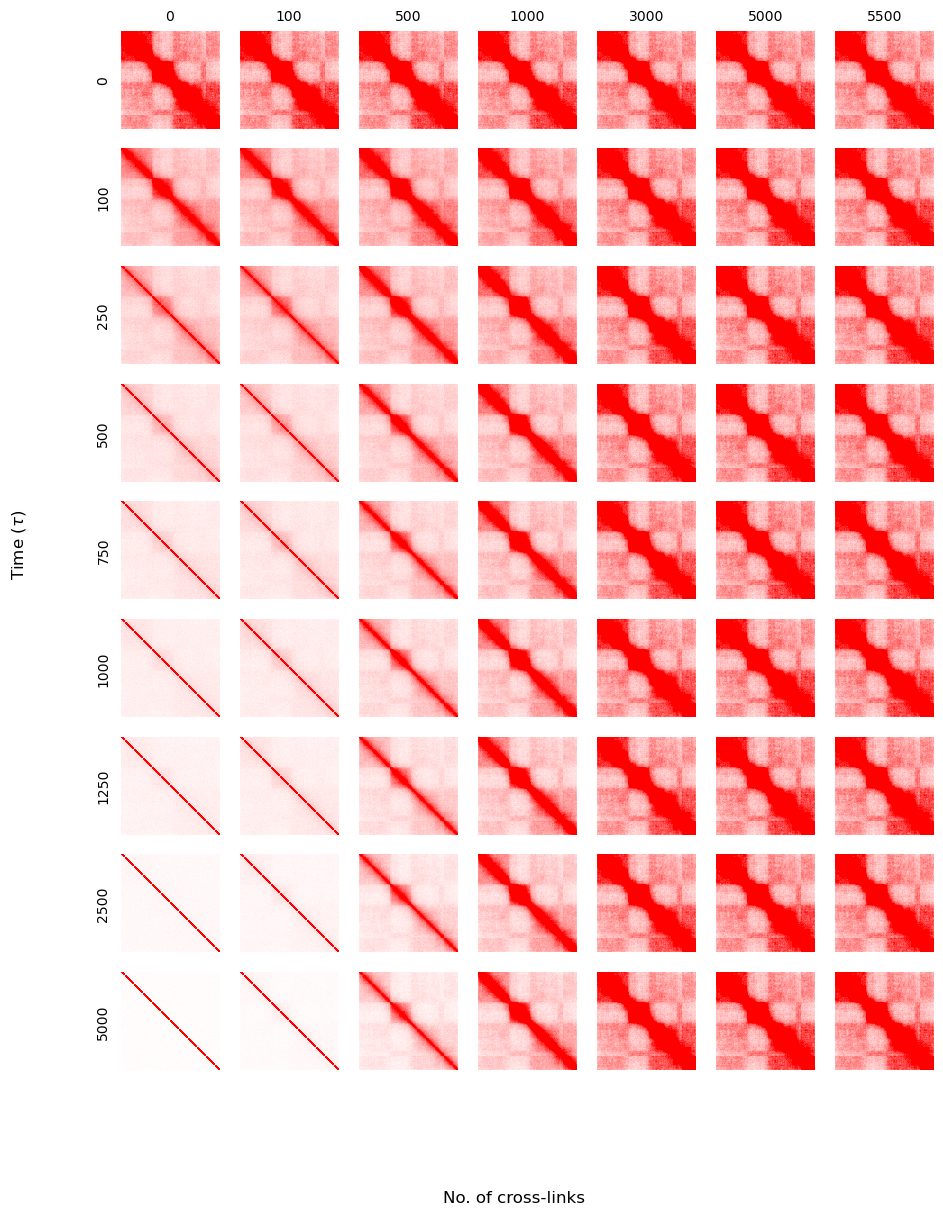

In [ ]:
No_xlbeads = [0, 100, 500, 1000, 3000, 5000, 5500]
times = [0,100,250,500,750,1000,1250,2500,5000]

scalef = 1.5

fig, ax = plt.subplots(9, 7, figsize=(7*scalef,9*scalef))

#ax[0, 0].matshow(dist_map_0000,  cmap='viridis' )
#ax[0, 0].axis('off')
#ax[0, 0].set_title("No. deg. cuts = 0")

max_v = 2.5e-1

ax[0, 0].matshow(coarse(cont_map_0000[0]-np.diag(np.diag(cont_map_0000[0])),5500,110), cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]), vmin=0, vmax=max_v, interpolation='none')
ax[0, 0].xaxis.set_tick_params(labelbottom=False, labeltop=False)
ax[0, 0].yaxis.set_tick_params(labelleft=False, labelright=False)
ax[0, 0].set_xticks([])
ax[0, 0].set_yticks([])
ax[0, 0].spines['top'].set_visible(False)
ax[0, 0].spines['bottom'].set_visible(False)
ax[0, 0].spines['left'].set_visible(False)
ax[0, 0].spines['right'].set_visible(False)
ax[0, 0].xaxis.set_label_position('top')
ax[0, 0].set_xlabel(No_xlbeads[0])
ax[0, 0].yaxis.set_label_position('left')
ax[0, 0].set_ylabel(times[0])

ax[0, 1].matshow(coarse(cont_map_0100[0]-np.diag(np.diag(cont_map_0100[0])),5500,110), cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]), vmin=0, vmax=max_v, interpolation='none')
ax[0, 2].matshow(coarse(cont_map_0500[0]-np.diag(np.diag(cont_map_0500[0])),5500,110), cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]), vmin=0, vmax=max_v, interpolation='none')
ax[0, 0].xaxis.set_tick_params(labelbottom=False, labeltop=False)
ax[0, 3].matshow(coarse(cont_map_1000[0]-np.diag(np.diag(cont_map_1000[0])),5500,110), cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]), vmin=0, vmax=max_v, interpolation='none')
ax[0, 4].matshow(coarse(cont_map_3000[0]-np.diag(np.diag(cont_map_3000[0])),5500,110), cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]), vmin=0, vmax=max_v, interpolation='none')
ax[0, 5].matshow(coarse(cont_map_5000[0]-np.diag(np.diag(cont_map_5000[0])),5500,110), cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]), vmin=0, vmax=max_v, interpolation='none')
ax[0, 6].matshow(coarse(cont_map_5500[0]-np.diag(np.diag(cont_map_5500[0])),5500,110), cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]), vmin=0, vmax=max_v, interpolation='none')


for i in range(1, 7):
    ax[0, i].xaxis.set_tick_params(labelbottom=False, labeltop=False)
    ax[0, i].yaxis.set_tick_params(labelleft=False, labelright=False)
    ax[0, i].set_xticks([])
    ax[0, i].set_yticks([])
    ax[0, i].spines['top'].set_visible(False)
    ax[0, i].spines['bottom'].set_visible(False)
    ax[0, i].spines['left'].set_visible(False)
    ax[0, i].spines['right'].set_visible(False)
    ax[0, i].xaxis.set_label_position('top')
    ax[0, i].set_xlabel(No_xlbeads[i])

for i in range(1, 9): 
    ax[i, 0].matshow(coarse(cont_map_0000[i]-np.diag(np.diag(cont_map_0000[i])),5500,110), cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]), vmin=0, vmax=max_v, interpolation='none')
    ax[i, 0].xaxis.set_tick_params(labelbottom=False, labeltop=False)
    ax[i, 0].yaxis.set_tick_params(labelleft=False, labelright=False)
    ax[i, 0].set_xticks([])
    ax[i, 0].set_yticks([])
    ax[i, 0].spines['top'].set_visible(False)
    ax[i, 0].spines['bottom'].set_visible(False)
    ax[i, 0].spines['left'].set_visible(False)
    ax[i, 0].spines['right'].set_visible(False)
    ax[i, 0].set_ylabel(times[i])
    
    #ax[i, 1].matshow(coarse(cont_map_0100[i]-np.diag(np.diag(cont_map_0100[i])),5500,110), cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]), vmin=0, vmax=max_v, interpolation='none')
    ax[i, 1].axis('off')

    #ax[i, 2].matshow(coarse(cont_map_0500[i]-np.diag(np.diag(cont_map_0500[i])),5500,110), cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]), vmin=0, vmax=max_v, interpolation='none')
    ax[i, 2].axis('off')
    
    #ax[i, 3].matshow(coarse(cont_map_1000[i]-np.diag(np.diag(cont_map_1000[i])),5500,110), cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]), vmin=0, vmax=max_v, interpolation='none')
    ax[i, 3].axis('off')
    
    ax[i, 4].matshow(coarse(cont_map_3000[i]-np.diag(np.diag(cont_map_3000[i])),5500,110), cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]), vmin=0, vmax=max_v, interpolation='none')
    ax[i, 4].axis('off')

    #ax[i, 5].matshow(coarse(cont_map_5000[i]-np.diag(np.diag(cont_map_5000[i])),5500,110), cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]), vmin=0, vmax=max_v, interpolation='none')
    ax[i, 5].axis('off')     
    
    #ax[i, 6].matshow(coarse(cont_map_5000[i]-np.diag(np.diag(cont_map_5000[i])),5500,110), cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]), vmin=0, vmax=max_v, interpolation='none')
    ax[i, 6].axis('off')  

fig.supxlabel('No. of cross-links')
fig.supylabel('Time ('+r'$\tau$)')
#fig.suptitle("Time evolution of contact maps for different numbers of crosslinks")

plt.show()

In [ ]:
#Contact-probability fits for extraction of scaling exponents

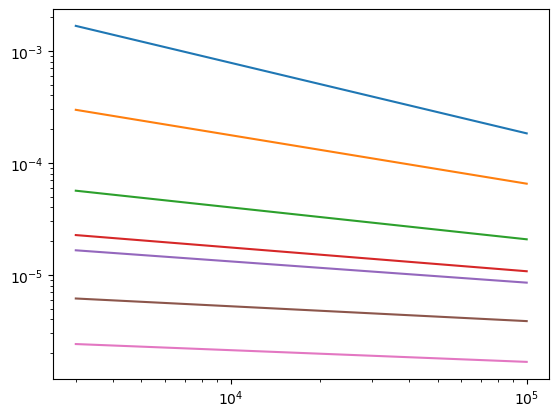

In [83]:
from scipy.optimize import curve_fit

def power_fit(x, a, alpha):
    return a*x**alpha

#print(len(scaled_xticks), len(cont_prob_5500))

params_0000, covariance_0000 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0000[0][49:499], maxfev=10000)
params_0100, covariance_0100 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0000[1][49:499], maxfev=10000)
params_0250, covariance_0250 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0000[2][49:499], maxfev=10000)
params_0500, covariance_0500 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0000[3][49:499], maxfev=10000)
params_0750, covariance_0750 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0000[4][49:499], maxfev=10000)
params_1000, covariance_1000 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0000[5][49:499], maxfev=10000)
params_1250, covariance_1250 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0000[6][49:499], maxfev=10000)
params_2500, covariance_2500 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0000[7][49:499], maxfev=10000)
params_5000, covariance_5000 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0000[8][49:499], maxfev=10000)


x= scaled_xticks[14:499]
plt.plot(x, power_fit(x, params_0000[0], params_0000[1]))
plt.plot(x, power_fit(x, params_0100[0], params_0100[1]))
plt.plot(x, power_fit(x, params_0500[0], params_0500[1]))
plt.plot(x, power_fit(x, params_1000[0], params_1000[1]))
plt.plot(x, power_fit(x, params_1250[0], params_1250[1]))
plt.plot(x, power_fit(x, params_2500[0], params_2500[1]))
plt.plot(x, power_fit(x, params_5000[0], params_5000[1]))

plt.yscale("log")
plt.xscale("log")

slope_0000 = np.abs(np.array([params_0000[1],params_0100[1],params_0250[1],params_0500[1],params_0750[1],params_1000[1],params_1250[1],params_2500[1],params_5000[1]]))

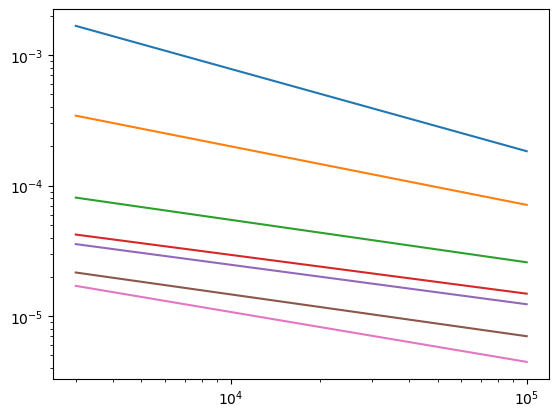

In [84]:
from scipy.optimize import curve_fit

def power_fit(x, a, alpha):
    return a*x**alpha

#print(len(scaled_xticks), len(cont_prob_5500))


params_0000, covariance_0000 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0100[0][49:499], maxfev=10000)
params_0100, covariance_0100 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0100[1][49:499], maxfev=10000)
params_0250, covariance_0250 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0100[2][49:499], maxfev=10000)
params_0500, covariance_0500 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0100[3][49:499], maxfev=10000)
params_0750, covariance_0750 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0100[4][49:499], maxfev=10000)
params_1000, covariance_1000 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0100[5][49:499], maxfev=10000)
params_1250, covariance_1250 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0100[6][49:499], maxfev=10000)
params_2500, covariance_2500 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0100[7][49:499], maxfev=10000)
params_5000, covariance_5000 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0100[8][49:499], maxfev=10000)


x= scaled_xticks[14:499]
plt.plot(x, power_fit(x, params_0000[0], params_0000[1]))
plt.plot(x, power_fit(x, params_0100[0], params_0100[1]))
plt.plot(x, power_fit(x, params_0500[0], params_0500[1]))
plt.plot(x, power_fit(x, params_1000[0], params_1000[1]))
plt.plot(x, power_fit(x, params_1250[0], params_1250[1]))
plt.plot(x, power_fit(x, params_2500[0], params_2500[1]))
plt.plot(x, power_fit(x, params_5000[0], params_5000[1]))

plt.yscale("log")
plt.xscale("log")

slope_0100 = np.abs(np.array([params_0000[1],params_0100[1],params_0250[1],params_0500[1],params_0750[1],params_1000[1],params_1250[1],params_2500[1],params_5000[1]]))

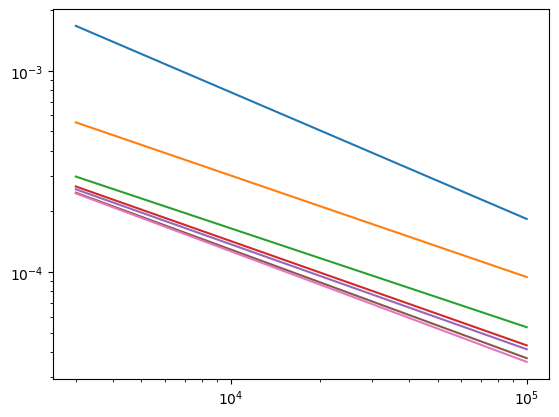

In [85]:
from scipy.optimize import curve_fit

def power_fit(x, a, alpha):
    return a*x**alpha



params_0000, covariance_0000 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0500[0][49:499], maxfev=10000)
params_0100, covariance_0100 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0500[1][49:499], maxfev=10000)
params_0250, covariance_0250 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0500[2][49:499], maxfev=10000)
params_0500, covariance_0500 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0500[3][49:499], maxfev=10000)
params_0750, covariance_0750 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0500[4][49:499], maxfev=10000)
params_1000, covariance_1000 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0500[5][49:499], maxfev=10000)
params_1250, covariance_1250 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0500[6][49:499], maxfev=10000)
params_2500, covariance_2500 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0500[7][49:499], maxfev=10000)
params_5000, covariance_5000 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_0500[8][49:499], maxfev=10000)


x= scaled_xticks[14:499]
plt.plot(x, power_fit(x, params_0000[0], params_0000[1]))
plt.plot(x, power_fit(x, params_0100[0], params_0100[1]))
plt.plot(x, power_fit(x, params_0500[0], params_0500[1]))
plt.plot(x, power_fit(x, params_1000[0], params_1000[1]))
plt.plot(x, power_fit(x, params_1250[0], params_1250[1]))
plt.plot(x, power_fit(x, params_2500[0], params_2500[1]))
plt.plot(x, power_fit(x, params_5000[0], params_5000[1]))

plt.yscale("log")
plt.xscale("log")

slope_0500 = np.abs(np.array([params_0000[1],params_0100[1],params_0250[1],params_0500[1],params_0750[1],params_1000[1],params_1250[1],params_2500[1],params_5000[1]]))

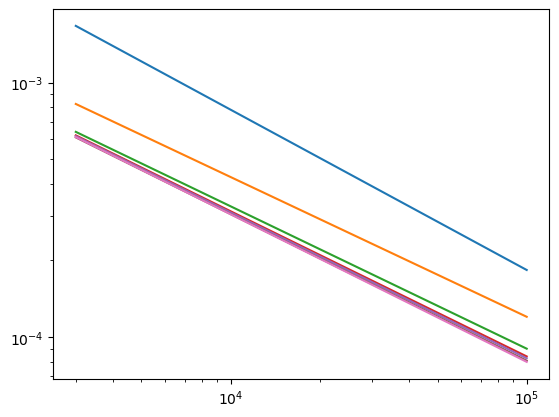

In [86]:
from scipy.optimize import curve_fit

def power_fit(x, a, alpha):
    return a*x**alpha



params_0000, covariance_0000 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_1000[0][49:499], maxfev=10000)
params_0100, covariance_0100 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_1000[1][49:499], maxfev=10000)
params_0250, covariance_0250 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_1000[2][49:499], maxfev=10000)
params_0500, covariance_0500 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_1000[3][49:499], maxfev=10000)
params_0750, covariance_0750 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_1000[4][49:499], maxfev=10000)
params_1000, covariance_1000 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_1000[5][49:499], maxfev=10000)
params_1250, covariance_1250 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_1000[6][49:499], maxfev=10000)
params_2500, covariance_2500 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_1000[7][49:499], maxfev=10000)
params_5000, covariance_5000 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_1000[8][49:499], maxfev=10000)


x= scaled_xticks[14:499]
plt.plot(x, power_fit(x, params_0000[0], params_0000[1]))
plt.plot(x, power_fit(x, params_0100[0], params_0100[1]))
plt.plot(x, power_fit(x, params_0500[0], params_0500[1]))
plt.plot(x, power_fit(x, params_1000[0], params_1000[1]))
plt.plot(x, power_fit(x, params_1250[0], params_1250[1]))
plt.plot(x, power_fit(x, params_2500[0], params_2500[1]))
plt.plot(x, power_fit(x, params_5000[0], params_5000[1]))

plt.yscale("log")
plt.xscale("log")

slope_1000 = np.abs(np.array([params_0000[1],params_0100[1],params_0250[1],params_0500[1],params_0750[1],params_1000[1],params_1250[1],params_2500[1],params_5000[1]]))

[0.63070613 0.6144143  0.61614339 0.61841477 0.61904693 0.61968753
 0.61915119 0.61922893 0.61965984]


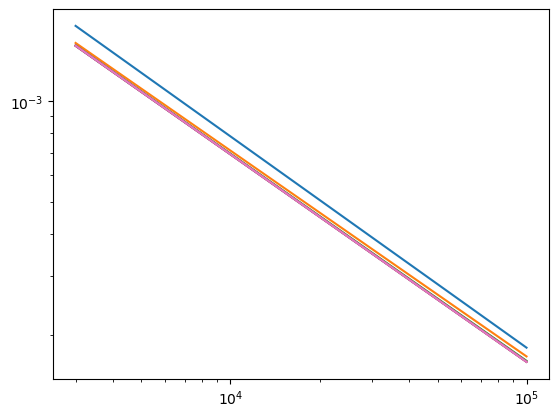

In [119]:
from scipy.optimize import curve_fit

def power_fit(x, a, alpha):
    return a*x**alpha



params_0000, covariance_0000 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_3000[0][49:499], maxfev=10000)
params_0100, covariance_0100 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_3000[1][49:499], maxfev=10000)
params_0250, covariance_0250 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_3000[2][49:499], maxfev=10000)
params_0500, covariance_0500 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_3000[3][49:499], maxfev=10000)
params_0750, covariance_0750 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_3000[4][49:499], maxfev=10000)
params_1000, covariance_1000 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_3000[5][49:499], maxfev=10000)
params_1250, covariance_1250 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_3000[6][49:499], maxfev=10000)
params_2500, covariance_2500 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_3000[7][49:499], maxfev=10000)
params_5000, covariance_5000 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_3000[8][49:499], maxfev=10000)



x= scaled_xticks[14:499]
plt.plot(x, power_fit(x, params_0000[0], params_0000[1]))
plt.plot(x, power_fit(x, params_0100[0], params_0100[1]))
plt.plot(x, power_fit(x, params_0500[0], params_0500[1]))
plt.plot(x, power_fit(x, params_1000[0], params_1000[1]))
plt.plot(x, power_fit(x, params_1250[0], params_1250[1]))
plt.plot(x, power_fit(x, params_2500[0], params_2500[1]))
plt.plot(x, power_fit(x, params_5000[0], params_5000[1]))

plt.yscale("log")
plt.xscale("log")

slope_3000 = np.abs(np.array([params_0000[1],params_0100[1],params_0250[1],params_0500[1],params_0750[1],params_1000[1],params_1250[1],params_2500[1],params_5000[1]]))
print(slope_3000)

In [48]:
scaled_xticks[499]

100018.15205529284

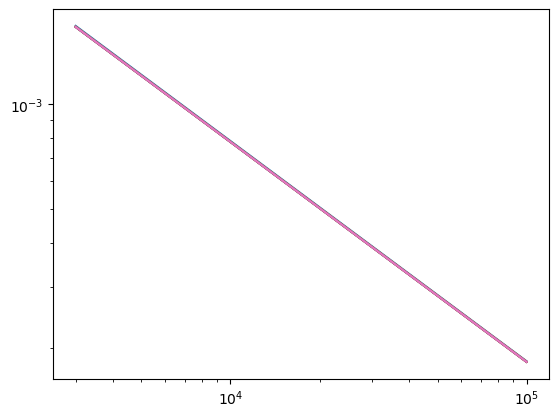

In [88]:
from scipy.optimize import curve_fit

def power_fit(x, a, alpha):
    return a*x**alpha

#print(len(scaled_xticks), len(cont_prob_5500))


params_0000, covariance_0000 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_5000[0][49:499], maxfev=10000)
params_0100, covariance_0100 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_5000[1][49:499], maxfev=10000)
params_0250, covariance_0250 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_5000[2][49:499], maxfev=10000)
params_0500, covariance_0500 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_5000[3][49:499], maxfev=10000)
params_0750, covariance_0750 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_5000[4][49:499], maxfev=10000)
params_1000, covariance_1000 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_5000[5][49:499], maxfev=10000)
params_1250, covariance_1250 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_5000[6][49:499], maxfev=10000)
params_2500, covariance_2500 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_5000[7][49:499], maxfev=10000)
params_5000, covariance_5000 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_5000[8][49:499], maxfev=10000)


x= scaled_xticks[14:499]
plt.plot(x, power_fit(x, params_0000[0], params_0000[1]))
plt.plot(x, power_fit(x, params_0100[0], params_0100[1]))
plt.plot(x, power_fit(x, params_0500[0], params_0500[1]))
plt.plot(x, power_fit(x, params_1000[0], params_1000[1]))
plt.plot(x, power_fit(x, params_1250[0], params_1250[1]))
plt.plot(x, power_fit(x, params_2500[0], params_2500[1]))
plt.plot(x, power_fit(x, params_5000[0], params_5000[1]))

plt.yscale("log")
plt.xscale("log")

slope_5000 = np.abs(np.array([params_0000[1],params_0100[1],params_0250[1],params_0500[1],params_0750[1],params_1000[1],params_1250[1],params_2500[1],params_5000[1]]))

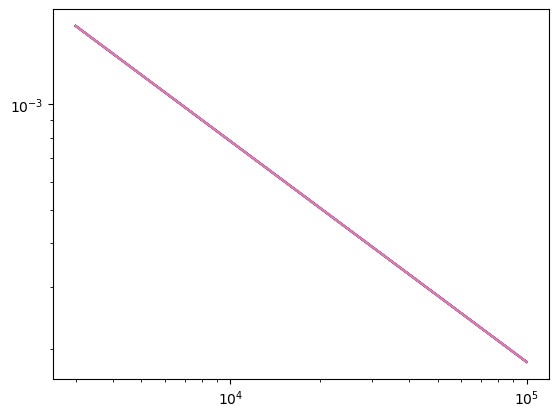

In [89]:
from scipy.optimize import curve_fit

def power_fit(x, a, alpha):
    return a*x**alpha

#print(len(scaled_xticks), len(cont_prob_5500))


params_0000, covariance_0000 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_5500[0][49:499], maxfev=10000)
params_0100, covariance_0100 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_5500[1][49:499], maxfev=10000)
params_0250, covariance_0250 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_5500[2][49:499], maxfev=10000)
params_0500, covariance_0500 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_5500[3][49:499], maxfev=10000)
params_0750, covariance_0750 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_5500[4][49:499], maxfev=10000)
params_1000, covariance_1000 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_5500[5][49:499], maxfev=10000)
params_1250, covariance_1250 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_5500[6][49:499], maxfev=10000)
params_2500, covariance_2500 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_5500[7][49:499], maxfev=10000)
params_5000, covariance_5000 = curve_fit(f = power_fit, xdata = scaled_xticks[49:499], ydata = cont_prob_5500[8][49:499], maxfev=10000)


x= scaled_xticks[14:499]
plt.plot(x, power_fit(x, params_0000[0], params_0000[1]))
plt.plot(x, power_fit(x, params_0100[0], params_0100[1]))
plt.plot(x, power_fit(x, params_0500[0], params_0500[1]))
plt.plot(x, power_fit(x, params_1000[0], params_1000[1]))
plt.plot(x, power_fit(x, params_1250[0], params_1250[1]))
plt.plot(x, power_fit(x, params_2500[0], params_2500[1]))
plt.plot(x, power_fit(x, params_5000[0], params_5000[1]))

plt.yscale("log")
plt.xscale("log")

slope_5500 = np.abs(np.array([params_0000[1],params_0100[1],params_0250[1],params_0500[1],params_0750[1],params_1000[1],params_1250[1],params_2500[1],params_5000[1]]))

In [ ]:
#Root mean squared displacement of nucleosomes as function of time for different crosslinking efficiencies.

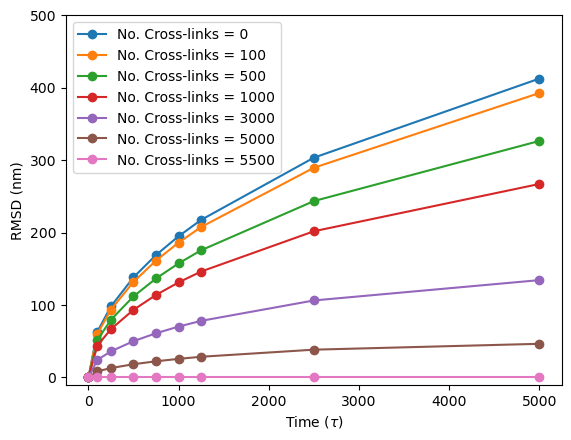

In [151]:
degrade_legend = ['No. Cross-links = '+str(0), 'No. Cross-links = '+str(100), 'No. Cross-links = '+str(500),'No. Cross-links = '+str(1000),'No. Cross-links = '+str(3000),'No. Cross-links = '+str(5000),'No. Cross-links = '+str(5500)]

plt.plot(iframes_0000, 10*np.sqrt(msd_0000[0:9]), marker = 'o', label = 'eee')
plt.plot(iframes_0100, 10*np.sqrt(msd_0100[0:9]), marker = 'o')
plt.plot(iframes_0500, 10*np.sqrt(msd_0500[0:9]), marker = 'o')
plt.plot(iframes_1000, 10*np.sqrt(msd_1000[0:9]), marker = 'o')
plt.plot(iframes_3000, 10*np.sqrt(msd_3000[0:9]), marker = 'o')
plt.plot(iframes_5000, 10*np.sqrt(msd_5000[0:9]), marker = 'o')
plt.plot(iframes_5500, 10*np.sqrt(msd_5500[0:9]), marker = 'o')

plt.ylim([-10,500])
plt.ylabel('RMSD (nm)')
#plt.yscale("log")
#plt.xscale("log")
#plt.xlim([1,5500])
#plt.ylim([1e1,1e1])

plt.legend(degrade_legend, loc='upper left') #, bbox_to_anchor=(1.9, 1.0))

#plt.xlim([scale_factor*1,scale_factor*5500])
plt.xlabel('Time ('+r'$\tau$)')

plt.show()

In [ ]:
#Scaling exponent of contact probability as a function of RMSD for different crosslinking efficiencies and time slices

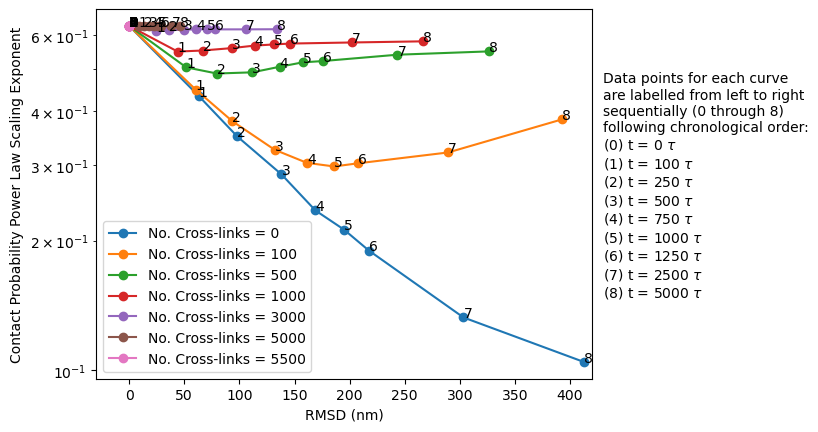

In [121]:
N_xlbeads    = [0, 100, 500, 1000, 3000, 5000, 5500] 
No_N_xlbeads = len(N_xlbeads)
No_frames = len(iframes_0100)
degrade_legend = ['No. Cross-links = '+str(0), 'No. Cross-links = '+str(100), 'No. Cross-links = '+str(500),'No. Cross-links = '+str(1000),'No. Cross-links = '+str(3000),'No. Cross-links = '+str(5000),'No. Cross-links = '+str(5500)]


#plt.plot(msd_t_0000, slope_t_0000, marker = 'o')
plt.plot(10*np.sqrt(msd_0000[0:9]), slope_0000[0:9], marker = 'o')
plt.plot(10*np.sqrt(msd_0100[0:9]), slope_0100[0:9], marker = 'o')
plt.plot(10*np.sqrt(msd_0500[0:9]), slope_0500[0:9], marker = 'o')
plt.plot(10*np.sqrt(msd_1000[0:9]), slope_1000[0:9], marker = 'o')
plt.plot(10*np.sqrt(msd_3000[0:9]), slope_3000[0:9], marker = 'o')
plt.plot(10*np.sqrt(msd_5000[0:9]), slope_5000[0:9], marker = 'o')
plt.plot(10*np.sqrt(msd_5500[0:9]), slope_5500[0:9], marker = 'o')

plt.legend(degrade_legend, loc='lower left') 
plt.xlim([-30,420])
#plt.ylabel('Power law exponent')
plt.yscale("log")
#plt.xscale("log")
#plt.title("Power law exponents of contact prob. vs. MSD of nucleosomes")
#plt.xlim([1,5500])
#plt.ylim([1e1,1e1])


data_point_labels = [0, 1, 2, 3, 4, 5, 6, 7, 8]
for i,j,k in zip(10*np.sqrt(msd_0000[0:9]),slope_0000[0:9],data_point_labels):
    plt.text(i,j,k)
for i,j,k in zip(10*np.sqrt(msd_0100[0:9]),slope_0100[0:9],data_point_labels):
    plt.text(i,j,k)
for i,j,k in zip(10*np.sqrt(msd_0500[0:9]),slope_0500[0:9],data_point_labels):
    plt.text(i,j,k)
for i,j,k in zip(10*np.sqrt(msd_1000[0:9]),slope_1000[0:9],data_point_labels):
    plt.text(i,j,k)
for i,j,k in zip(10*np.sqrt(msd_3000[0:9]),slope_3000[0:9],data_point_labels):
    plt.text(i,j,k)
for i,j,k in zip(10*np.sqrt(msd_5000[0:9]),slope_5000[0:9],data_point_labels):
    plt.text(i,j,k)
for i,j,k in zip(10*np.sqrt(msd_5500[0:9]),slope_5500[0:9],data_point_labels):
    plt.text(i,j,k)
    

    
    
text = ("Data points for each curve" "\n" 
        "are labelled from left to right" "\n" 
        "sequentially (0 through 8)" "\n" 
        "following chronological order:" "\n"
       "(0) t = "+str(0)+r" $\tau$" "\n"
       "(1) t = "+str(100)+r" $\tau$" "\n"
       "(2) t = "+str(250)+r" $\tau$" "\n"
       "(3) t = "+str(500)+r" $\tau$" "\n"
       "(4) t = "+str(750)+r" $\tau$" "\n"
       "(5) t = "+str(1000)+r" $\tau$" "\n"
       "(6) t = "+str(1250)+r" $\tau$" "\n"
       "(7) t = "+str(2500)+r" $\tau$" "\n"
       "(8) t = "+str(5000)+r" $\tau$ ")

plt.text(430, 0.15, text, wrap=True)



#plt.xlim([scale_factor*1,scale_factor*5500])
plt.xlabel(r'RMSD (nm)')
plt.ylabel(r'Contact Probability Power Law Scaling Exponent')

plt.show()

In [ ]:
#Heat map of nucleosome RMSD as a function of crosslinking efficiency and time

In [122]:
MSD     = [msd_0000, msd_0100, msd_0500, msd_1000, msd_3000, msd_5000, msd_5500,]
Slopes  = [slope_0000, slope_0100, slope_0500, slope_1000, slope_3000, slope_5000, slope_5500,]
No_xlbeads = [0, 100, 500, 1000, 3000, 5000, 5500]
times = [0,100,250,500,750,1000,1250,2500,5000]

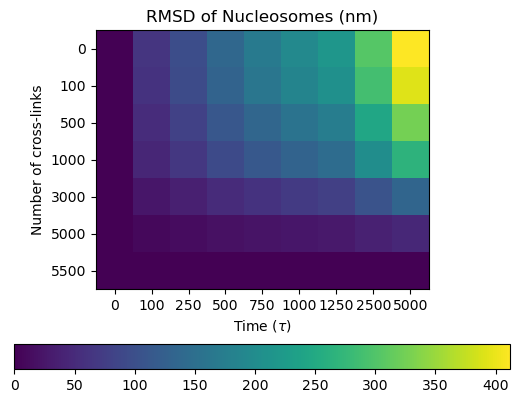

In [174]:
msd_fig = plt.figure()
ax  = msd_fig.add_subplot(111)
cax = ax.matshow(10*np.sqrt(MSD), interpolation='nearest',  cmap='viridis')
msd_fig.colorbar(cax, orientation="horizontal")

xaxis = np.arange(len(No_xlbeads))
yaxis = np.arange(len(times))

ax.set_xticks(yaxis)
ax.set_yticks(xaxis)
ax.set_xticklabels(times)
ax.set_yticklabels(No_xlbeads)
ax.xaxis.set_ticks_position('bottom')

ax.set_title("RMSD of Nucleosomes (nm)")
ax.set_xlabel("Time (" + r'$\tau$)')
ax.set_ylabel("Number of cross-links")

plt.show()

In [ ]:
#Heat map of contact probability power-law scaling as a function of crosslinking efficiency and time

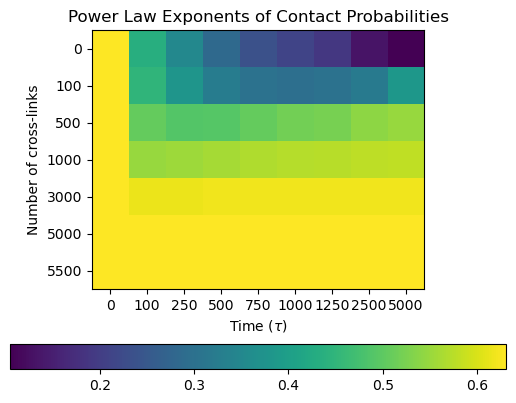

In [124]:
ple_fig = plt.figure()
ax  = ple_fig.add_subplot(111)
cax = ax.matshow(Slopes, interpolation='nearest')
ple_fig.colorbar(cax, orientation="horizontal")

xaxis = np.arange(len(No_xlbeads))
yaxis = np.arange(len(times))

ax.set_xticks(yaxis)
ax.set_yticks(xaxis)
ax.set_xticklabels(times)
ax.set_yticklabels(No_xlbeads)
ax.xaxis.set_ticks_position('bottom')


ax.set_title("Power Law Exponents of Contact Probabilities")
ax.set_xlabel("Time (" + r'$\tau$)')
ax.set_ylabel("Number of cross-links")

plt.show()